In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content
!git clone https://github.com/ADHULJITH/Smart-TryOn-System

/content
fatal: destination path 'Smart-TryOn-System' already exists and is not an empty directory.


In [3]:
# ============================================================
# CELL 1 — Q4 PROJECT SETUP
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/Smart-TryOn-System"
)

print("=" * 70)
print("Q4 — AUTOMATED QUALITY EVALUATION")
print("=" * 70)

print("Project:", PROJECT_ROOT)
print("Exists :", PROJECT_ROOT.exists())

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project not found:\n{PROJECT_ROOT}"
    )

print("✅ Project found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Q4 — AUTOMATED QUALITY EVALUATION
Project: /content/Smart-TryOn-System
Exists : True
✅ Project found.


In [4]:
# ============================================================
# CELL 2 — Q4 PATH CONFIGURATION
# ============================================================

DATA_DIR = (
    PROJECT_ROOT /
    "Data"
)

TEST_PAIRS_DIR = (
    DATA_DIR /
    "test_pairs"
)

PERSON_DIR = (
    TEST_PAIRS_DIR /
    "person"
)

GARMENT_DIR = (
    TEST_PAIRS_DIR /
    "garment"
)

MANIFEST_PATH = (
    TEST_PAIRS_DIR /
    "pairs_manifest.csv"
)

# ------------------------------------------------------------
# Q2
# ------------------------------------------------------------

Q2_DIR = (
    DATA_DIR /
    "Output" /
    "Q2"
)

PARSING_DIR = (
    Q2_DIR /
    "parsing_maps"
)

AGNOSTIC_DIR = (
    Q2_DIR /
    "agnostic"
)

GARMENT_MASK_DIR = (
    Q2_DIR /
    "garment_masks"
)

# ------------------------------------------------------------
# Q3
# ------------------------------------------------------------

Q3_DIR = (
    DATA_DIR /
    "Output" /
    "Q3"
)

Q3_RESULTS_DIR = (
    Q3_DIR /
    "tryon_results"
)

# ------------------------------------------------------------
# Q4
# ------------------------------------------------------------

Q4_DIR = (
    DATA_DIR /
    "Output" /
    "Q4"
)

GARMENT_FIDELITY_DIR = (
    Q4_DIR /
    "garment_fidelity"
)

IDENTITY_DIR = (
    Q4_DIR /
    "identity"
)

VLM_JUDGE_DIR = (
    Q4_DIR /
    "vlm_judge"
)

VISUALIZATION_DIR = (
    Q4_DIR /
    "visualizations"
)

for folder in [
    Q4_DIR,
    GARMENT_FIDELITY_DIR,
    IDENTITY_DIR,
    VLM_JUDGE_DIR,
    VISUALIZATION_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 70)
print("Q4 PATHS")
print("=" * 70)

paths = {
    "Manifest": MANIFEST_PATH,
    "Q2 Parsing": PARSING_DIR,
    "Q2 Agnostic": AGNOSTIC_DIR,
    "Q2 Garment Masks": GARMENT_MASK_DIR,
    "Q3 Results": Q3_RESULTS_DIR,
    "Q4 Output": Q4_DIR
}

for name, path in paths.items():
    print(f"{name:20} : {path}")

Q4 PATHS
Manifest             : /content/Smart-TryOn-System/Data/test_pairs/pairs_manifest.csv
Q2 Parsing           : /content/Smart-TryOn-System/Data/Output/Q2/parsing_maps
Q2 Agnostic          : /content/Smart-TryOn-System/Data/Output/Q2/agnostic
Q2 Garment Masks     : /content/Smart-TryOn-System/Data/Output/Q2/garment_masks
Q3 Results           : /content/Smart-TryOn-System/Data/Output/Q3/tryon_results
Q4 Output            : /content/Smart-TryOn-System/Data/Output/Q4


In [5]:
# ============================================================
# CELL 3 — VERIFY Q2/Q3 INPUTS
# ============================================================

import pandas as pd

print("=" * 70)
print("Q4 INPUT VALIDATION")
print("=" * 70)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST_PATH}"
    )

df = pd.read_csv(
    MANIFEST_PATH
)

q3_ids = [
    "pair_01",
    "pair_02",
    "pair_03",
    "pair_04",
    "pair_05"
]

q4_df = df[
    df["pair_id"].isin(q3_ids)
].copy()

q4_df = (
    q4_df
    .set_index("pair_id")
    .loc[q3_ids]
    .reset_index()
)

print("\nQ4 pairs:")
print(
    q4_df[
        [
            "pair_id",
            "person_image",
            "garment_image"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)

for _, row in q4_df.iterrows():

    pair_id = row["pair_id"]

    person_path = (
        TEST_PAIRS_DIR /
        str(row["person_image"])
    )

    garment_path = (
        TEST_PAIRS_DIR /
        str(row["garment_image"])
    )

    result_path = (
        Q3_RESULTS_DIR /
        f"{pair_id}_tryon.png"
    )

    print(f"\n{pair_id}")

    print(
        "Person :",
        "✅" if person_path.exists() else "❌"
    )

    print(
        "Garment:",
        "✅" if garment_path.exists() else "❌"
    )

    print(
        "Q3     :",
        "✅" if result_path.exists() else "❌"
    )

print("\n" + "=" * 70)

Q4 INPUT VALIDATION

Q4 pairs:
pair_id         person_image          garment_image
pair_01 person/person_01.png garment/garment_01.jpg
pair_02 person/person_02.png garment/garment_02.jpg
pair_03 person/person_03.png garment/garment_03.jpg
pair_04 person/person_04.png garment/garment_04.jpg
pair_05 person/person_05.png garment/garment_05.jpg


pair_01
Person : ✅
Garment: ✅
Q3     : ✅

pair_02
Person : ✅
Garment: ✅
Q3     : ✅

pair_03
Person : ✅
Garment: ✅
Q3     : ✅

pair_04
Person : ✅
Garment: ✅
Q3     : ✅

pair_05
Person : ✅
Garment: ✅
Q3     : ✅



In [6]:
# ============================================================
# CELL 4 — Q4 DEPENDENCIES
# ============================================================

!pip install -q open_clip_torch scikit-image opencv-python

In [7]:
# ============================================================
# CELL 5 — IMPORT TEST
# ============================================================

import torch
import numpy as np
import pandas as pd

from PIL import Image

import cv2

from skimage.metrics import structural_similarity

import open_clip

print("=" * 70)
print("Q4 IMPORT TEST")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )

print("OpenCLIP: OK")
print("OpenCV  : OK")
print("SSIM    : OK")

print("✅ Q4 imports successful.")

Q4 IMPORT TEST
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
OpenCLIP: OK
OpenCV  : OK
SSIM    : OK
✅ Q4 imports successful.


In [8]:
# ============================================================
# CELL 6 — GPU MEMORY CHECK
# ============================================================

import gc
import torch

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    free_memory, total_memory = (
        torch.cuda.mem_get_info()
    )

    print("=" * 70)
    print("GPU MEMORY")
    print("=" * 70)

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "Free :",
        round(
            free_memory / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "Total:",
        round(
            total_memory / 1024**3,
            2
        ),
        "GB"
    )

GPU MEMORY
GPU: Tesla T4
Free : 14.46 GB
Total: 14.56 GB


In [9]:
# ============================================================
# CELL 7 — LOAD OPENCLIP
# ============================================================

import torch
import open_clip

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "openai"

print("=" * 70)
print("LOADING OPENCLIP")
print("=" * 70)

clip_model, _, clip_preprocess = (
    open_clip.create_model_and_transforms(
        CLIP_MODEL_NAME,
        pretrained=CLIP_PRETRAINED,
        device=DEVICE
    )
)

clip_model.eval()

print("Model      :", CLIP_MODEL_NAME)
print("Pretrained :", CLIP_PRETRAINED)
print("Device     :", DEVICE)

print("✅ OpenCLIP loaded.")

LOADING OPENCLIP


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model      : ViT-B-32
Pretrained : openai
Device     : cuda
✅ OpenCLIP loaded.


In [10]:
# ============================================================
# CELL 8 — OPENCLIP EMBEDDING FUNCTION
# ============================================================

import torch
import torch.nn.functional as F

def get_clip_embedding(image):

    image_tensor = (
        clip_preprocess(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.inference_mode():

        embedding = (
            clip_model.encode_image(
                image_tensor
            )
        )

        embedding = F.normalize(
            embedding,
            dim=-1
        )

    return embedding


def clip_similarity(
    image_a,
    image_b
):

    emb_a = get_clip_embedding(
        image_a
    )

    emb_b = get_clip_embedding(
        image_b
    )

    similarity = (
        torch.sum(
            emb_a * emb_b,
            dim=-1
        )
        .item()
    )

    return float(similarity)


print("✅ OpenCLIP functions ready.")

✅ OpenCLIP functions ready.


In [11]:
# ============================================================
# CELL 9 — Q2 PARSING → GARMENT REGION
# ============================================================

import numpy as np
from PIL import Image

# SCHP ATR labels
SCHP_LABELS = {
    0: "background",
    1: "hat",
    2: "hair",
    3: "sunglasses",
    4: "upper-clothes",
    5: "skirt",
    6: "pants",
    7: "dress",
    8: "belt",
    9: "left-shoe",
    10: "right-shoe",
    11: "left-leg",
    12: "right-leg",
    13: "left-arm",
    14: "right-arm",
    15: "bag",
    16: "scarf"
}

GARMENT_LABELS = {
    "upper-clothes",
    "dress",
    "skirt",
    "pants",
    "belt",
    "scarf"
}

GARMENT_IDS = {
    idx
    for idx, label in SCHP_LABELS.items()
    if label in GARMENT_LABELS
}

print(
    "Garment parsing IDs:",
    sorted(GARMENT_IDS)
)

Garment parsing IDs: [4, 5, 6, 7, 8, 16]


In [12]:
# ============================================================
# CELL 10 — EXTRACT OUTPUT GARMENT REGION
# ============================================================

def get_garment_bbox(
    parsing_path
):

    parsing = np.array(
        Image.open(
            parsing_path
        ).convert("L")
    )

    garment_mask = np.isin(
        parsing,
        list(GARMENT_IDS)
    )

    ys, xs = np.where(
        garment_mask
    )

    if len(xs) == 0:
        return None

    x1 = int(xs.min())
    y1 = int(ys.min())
    x2 = int(xs.max()) + 1
    y2 = int(ys.max()) + 1

    return (
        x1,
        y1,
        x2,
        y2
    )


def crop_output_garment(
    output_image,
    parsing_path,
    padding=20
):

    bbox = get_garment_bbox(
        parsing_path
    )

    if bbox is None:
        return output_image

    x1, y1, x2, y2 = bbox

    width, height = (
        output_image.size
    )

    x1 = max(
        0,
        x1 - padding
    )

    y1 = max(
        0,
        y1 - padding
    )

    x2 = min(
        width,
        x2 + padding
    )

    y2 = min(
        height,
        y2 + padding
    )

    return output_image.crop(
        (
            x1,
            y1,
            x2,
            y2
        )
    )


print(
    "✅ Garment region extraction ready."
)

✅ Garment region extraction ready.


In [13]:
# ============================================================
# CELL 11 — RESOLUTION-SAFE GARMENT CROP
# ============================================================

def crop_output_garment(
    output_image,
    parsing_path,
    padding_ratio=0.03
):

    parsing = Image.open(
        parsing_path
    ).convert("L")

    # Match parsing map to Q3 output
    parsing = parsing.resize(
        output_image.size,
        Image.Resampling.NEAREST
    )

    parsing_np = np.array(
        parsing
    )

    garment_mask = np.isin(
        parsing_np,
        list(GARMENT_IDS)
    )

    ys, xs = np.where(
        garment_mask
    )

    if len(xs) == 0:

        print(
            "⚠️ No garment region detected."
        )

        return output_image

    x1 = int(xs.min())
    y1 = int(ys.min())

    x2 = int(xs.max()) + 1
    y2 = int(ys.max()) + 1

    pad_x = int(
        output_image.width *
        padding_ratio
    )

    pad_y = int(
        output_image.height *
        padding_ratio
    )

    x1 = max(
        0,
        x1 - pad_x
    )

    y1 = max(
        0,
        y1 - pad_y
    )

    x2 = min(
        output_image.width,
        x2 + pad_x
    )

    y2 = min(
        output_image.height,
        y2 + pad_y
    )

    return output_image.crop(
        (
            x1,
            y1,
            x2,
            y2
        )
    )


print(
    "✅ Resolution-safe garment extraction ready."
)

✅ Resolution-safe garment extraction ready.


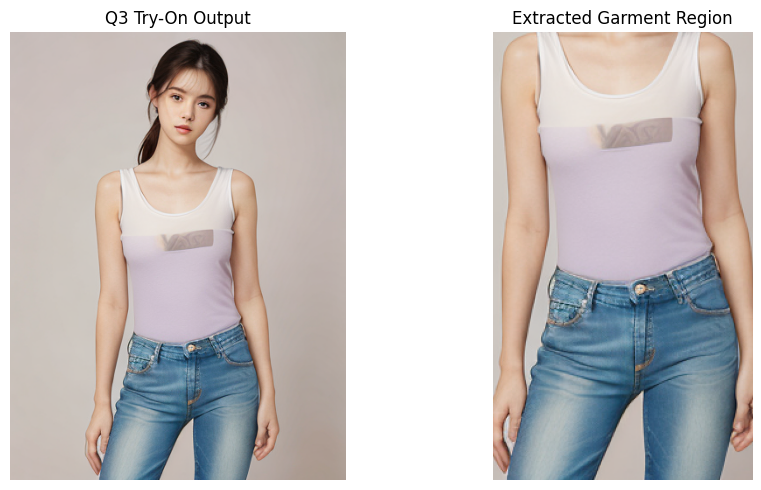

In [14]:
# ============================================================
# CELL 12 — TEST GARMENT REGION
# ============================================================

import matplotlib.pyplot as plt

row = q4_df[
    q4_df["pair_id"] == "pair_01"
].iloc[0]

person_name = Path(
    row["person_image"]
).name

parsing_path = (
    PARSING_DIR /
    f"{Path(person_name).stem}.png"
)

output_path = (
    Q3_RESULTS_DIR /
    "pair_01_tryon.png"
)

output_image = Image.open(
    output_path
).convert("RGB")

garment_region = crop_output_garment(
    output_image,
    parsing_path
)

plt.figure(
    figsize=(10, 5)
)

plt.subplot(1, 2, 1)
plt.imshow(output_image)
plt.title("Q3 Try-On Output")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(garment_region)
plt.title("Extracted Garment Region")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL 13 — GARMENT FIDELITY FUNCTION
# ============================================================

def calculate_garment_fidelity(
    garment_path,
    output_path,
    parsing_path
):

    garment_image = Image.open(
        garment_path
    ).convert("RGB")

    output_image = Image.open(
        output_path
    ).convert("RGB")

    generated_garment = (
        crop_output_garment(
            output_image,
            parsing_path
        )
    )

    similarity = clip_similarity(
        garment_image,
        generated_garment
    )

    score = max(
        0.0,
        min(
            100.0,
            similarity * 100.0
        )
    )

    return {
        "similarity": similarity,
        "score": score,
        "generated_region": generated_garment
    }


print(
    "✅ Garment fidelity evaluator ready."
)

✅ Garment fidelity evaluator ready.


In [16]:
# ============================================================
# CELL 14 — TEST GARMENT FIDELITY
# ============================================================

row = q4_df[
    q4_df["pair_id"] == "pair_01"
].iloc[0]

garment_path = (
    TEST_PAIRS_DIR /
    row["garment_image"]
)

output_path = (
    Q3_RESULTS_DIR /
    f"{row['pair_id']}_tryon.png"
)

parsing_path = (
    PARSING_DIR /
    f"{Path(row['person_image']).stem}.png"
)

fidelity_result = (
    calculate_garment_fidelity(
        garment_path,
        output_path,
        parsing_path
    )
)

print("=" * 70)
print("GARMENT FIDELITY — pair_01")
print("=" * 70)

print(
    "CLIP similarity:",
    round(
        fidelity_result["similarity"],
        4
    )
)

print(
    "Fidelity score:",
    round(
        fidelity_result["score"],
        2
    ),
    "/ 100"
)

GARMENT FIDELITY — pair_01
CLIP similarity: 0.7536
Fidelity score: 75.36 / 100


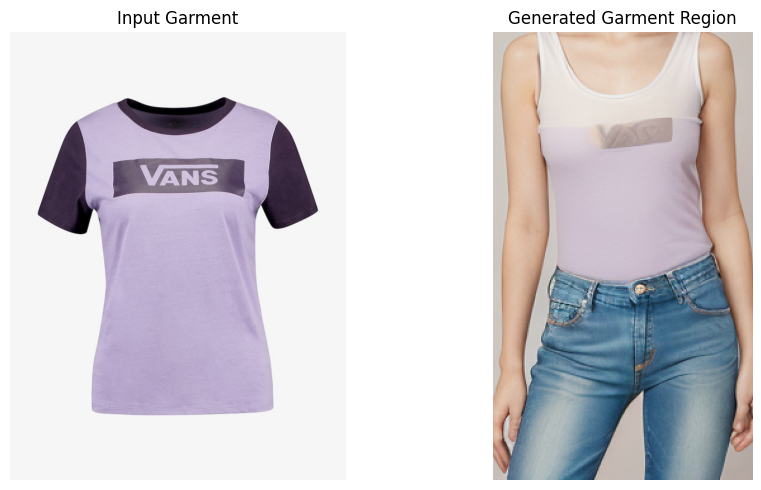

Saved: /content/Smart-TryOn-System/Data/Output/Q4/garment_fidelity/pair_01_garment_comparison.png


In [17]:
# ============================================================
# CELL 15 — GARMENT FIDELITY VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

garment_image = Image.open(
    garment_path
).convert("RGB")

generated_region = (
    fidelity_result["generated_region"]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    garment_image
)

axes[0].set_title(
    "Input Garment"
)

axes[1].imshow(
    generated_region
)

axes[1].set_title(
    "Generated Garment Region"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()

save_path = (
    GARMENT_FIDELITY_DIR /
    "pair_01_garment_comparison.png"
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Saved:",
    save_path
)

In [18]:
# ============================================================
# CELL 16 — RELEASE OPENCLIP MEMORY
# ============================================================

import gc
import torch

print(
    "Releasing OpenCLIP..."
)

del clip_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    "✅ OpenCLIP memory released."
)

if torch.cuda.is_available():

    free_memory, total_memory = (
        torch.cuda.mem_get_info()
    )

    print(
        "GPU free memory:",
        round(
            free_memory / 1024**3,
            2
        ),
        "GB"
    )

Releasing OpenCLIP...
✅ OpenCLIP memory released.
GPU free memory: 14.41 GB


In [19]:
# ============================================================
# CELL 17 — FACE DETECTOR
# ============================================================

import cv2

FACE_CASCADE_PATH = (
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

face_detector = cv2.CascadeClassifier(
    FACE_CASCADE_PATH
)

if face_detector.empty():
    raise RuntimeError(
        "Could not load OpenCV face detector."
    )

print(
    "✅ Face detector loaded."
)

✅ Face detector loaded.


In [20]:
# ============================================================
# CELL 18 — FACE REGION EXTRACTION
# ============================================================

def detect_face_bbox(image):

    image_np = np.array(
        image.convert("RGB")
    )

    gray = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2GRAY
    )

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        return None

    # Select largest face
    face = max(
        faces,
        key=lambda box:
        box[2] * box[3]
    )

    x, y, w, h = face

    return (
        int(x),
        int(y),
        int(x + w),
        int(y + h)
    )


def crop_face(
    image,
    bbox,
    padding=0.25
):

    if bbox is None:
        return None

    x1, y1, x2, y2 = bbox

    w = x2 - x1
    h = y2 - y1

    px = int(
        w * padding
    )

    py = int(
        h * padding
    )

    x1 = max(
        0,
        x1 - px
    )

    y1 = max(
        0,
        y1 - py
    )

    x2 = min(
        image.width,
        x2 + px
    )

    y2 = min(
        image.height,
        y2 + py
    )

    return image.crop(
        (
            x1,
            y1,
            x2,
            y2
        )
    )


print(
    "✅ Face extraction functions ready."
)

✅ Face extraction functions ready.


In [21]:
# ============================================================
# CELL 19 — FACE SSIM
# ============================================================

from skimage.metrics import structural_similarity
import numpy as np


def calculate_face_ssim(
    person_path,
    output_path
):

    person = Image.open(
        person_path
    ).convert("RGB")

    output = Image.open(
        output_path
    ).convert("RGB")

    bbox = detect_face_bbox(
        person
    )

    if bbox is None:

        return {
            "score": None,
            "status": "face_not_detected"
        }

    person_face = crop_face(
        person,
        bbox
    )

    # Same spatial region on generated image
    output_bbox = bbox

    output_face = crop_face(
        output,
        output_bbox
    )

    if output_face is None:

        return {
            "score": None,
            "status": "output_face_not_available"
        }

    person_face = person_face.resize(
        (160, 160),
        Image.Resampling.LANCZOS
    )

    output_face = output_face.resize(
        (160, 160),
        Image.Resampling.LANCZOS
    )

    person_gray = np.array(
        person_face.convert("L"),
        dtype=np.float32
    )

    output_gray = np.array(
        output_face.convert("L"),
        dtype=np.float32
    )

    score = structural_similarity(
        person_gray,
        output_gray,
        data_range=255
    )

    return {
        "score": float(score),
        "status": "success"
    }


print(
    "✅ Face SSIM evaluator ready."
)

✅ Face SSIM evaluator ready.


In [22]:
# ============================================================
# CELL 20 — TEST IDENTITY PRESERVATION
# ============================================================

row = q4_df[
    q4_df["pair_id"] == "pair_01"
].iloc[0]

person_path = (
    TEST_PAIRS_DIR /
    row["person_image"]
)

output_path = (
    Q3_RESULTS_DIR /
    f"{row['pair_id']}_tryon.png"
)

identity_result = calculate_face_ssim(
    person_path,
    output_path
)

print("=" * 70)
print("IDENTITY PRESERVATION — pair_01")
print("=" * 70)

print(
    "Status:",
    identity_result["status"]
)

print(
    "SSIM:",
    identity_result["score"]
)

IDENTITY PRESERVATION — pair_01
Status: success
SSIM: 0.43420814806049146


IDENTITY VISUALIZATION — pair_01

Original person:
/content/Smart-TryOn-System/Data/test_pairs/person/person_01.png

Q3 try-on output:
/content/Smart-TryOn-System/Data/Output/Q3/tryon_results/pair_01_tryon.png

Original size : (768, 1024)
Try-on size   : (384, 512)

Detected face bounding box: (318, 85, 494, 261)


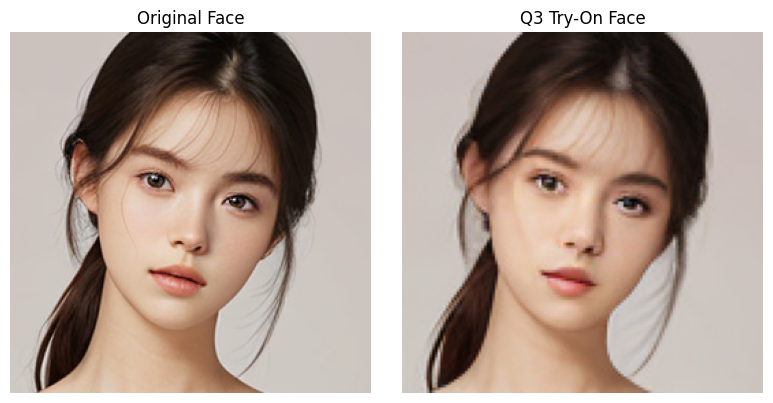


✅ Face comparison saved:
/content/Smart-TryOn-System/Data/Output/Q4/identity/pair_01_face_comparison.png


In [23]:
# ============================================================
# CELL 21 — IDENTITY VISUALIZATION
# Uses ONLY the original person image and Q3 try-on output.
# NO image generation is performed.
# ============================================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 70)
print("IDENTITY VISUALIZATION — pair_01")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify the actual files
# ------------------------------------------------------------

print("\nOriginal person:")
print(person_path)

print("\nQ3 try-on output:")
print(output_path)

if not Path(person_path).exists():
    raise FileNotFoundError(
        f"Original person image not found:\n{person_path}"
    )

if not Path(output_path).exists():
    raise FileNotFoundError(
        f"Q3 try-on output not found:\n{output_path}"
    )

# ------------------------------------------------------------
# 2. Load ACTUAL images
# ------------------------------------------------------------

person = Image.open(
    person_path
).convert("RGB")

output = Image.open(
    output_path
).convert("RGB"
)

print("\nOriginal size :", person.size)
print("Try-on size   :", output.size)

# ------------------------------------------------------------
# 3. Detect face on ORIGINAL person
# ------------------------------------------------------------

bbox = detect_face_bbox(person)

if bbox is None:

    print(
        "\n⚠️ No face detected in the original image."
    )

    print(
        "Displaying full images instead."
    )

    person_face = person
    output_face = output

else:

    print(
        "\nDetected face bounding box:",
        bbox
    )

    # --------------------------------------------------------
    # Crop the same approximate region from both images
    # --------------------------------------------------------

    person_face = crop_face(
        person,
        bbox
    )

    # The Q3 output may have a different resolution.
    # Scale the bounding box according to output dimensions.

    scale_x = output.width / person.width
    scale_y = output.height / person.height

    output_bbox = (
        int(bbox[0] * scale_x),
        int(bbox[1] * scale_y),
        int(bbox[2] * scale_x),
        int(bbox[3] * scale_y)
    )

    output_face = crop_face(
        output,
        output_bbox
    )

# ------------------------------------------------------------
# 4. Display actual face regions
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(person_face)
axes[0].set_title(
    "Original Face"
)

axes[1].imshow(output_face)
axes[1].set_title(
    "Q3 Try-On Face"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()

# ------------------------------------------------------------
# 5. Save visualization
# ------------------------------------------------------------

IDENTITY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

save_path = (
    IDENTITY_DIR /
    "pair_01_face_comparison.png"
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "\n✅ Face comparison saved:"
)

print(save_path)

In [37]:
# ============================================================
# CELL 22 — FLORENCE-2 COMPATIBILITY SETUP
# ============================================================

import sys
import subprocess

print("=" * 70)
print("SETTING UP FLORENCE-2 COMPATIBILITY")
print("=" * 70)

# Florence-2 has compatibility issues with some newer
# Transformers releases.
#
# We use a stable Transformers version for Florence-2
# rather than patching multiple internal model attributes.

TARGET_TRANSFORMERS = "4.49.0"

import transformers

print(
    "Current Transformers:",
    transformers.__version__
)

if transformers.__version__ != TARGET_TRANSFORMERS:

    print(
        f"Installing Transformers {TARGET_TRANSFORMERS}..."
    )

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--force-reinstall",
        f"transformers=={TARGET_TRANSFORMERS}"
    ])

    print()
    print("=" * 70)
    print("⚠️ INSTALLATION COMPLETE")
    print("=" * 70)

    print(
        "Colab runtime restart is required."
    )

    print()
    print(
        "After restart, run the notebook again "
        "from the beginning."
    )

else:

    print(
        "✅ Correct Transformers version already installed."
    )

print("=" * 70)

SETTING UP FLORENCE-2 COMPATIBILITY
Current Transformers: 4.49.0
✅ Correct Transformers version already installed.


In [39]:
# ============================================================
# CELL 22 — LOAD FLORENCE-2 FOR Q4 VLM JUDGE
# ============================================================

import gc
import torch
import transformers

print("=" * 70)
print("FLORENCE-2 ENVIRONMENT")
print("=" * 70)

print(
    "Transformers:",
    transformers.__version__
)

print(
    "PyTorch:",
    torch.__version__
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DTYPE = (
    torch.float16
    if DEVICE == "cuda"
    else torch.float32
)

FLORENCE_MODEL = (
    "microsoft/Florence-2-base"
)

print(
    "Model:",
    FLORENCE_MODEL
)

print(
    "Device:",
    DEVICE
)

print(
    "Dtype:",
    DTYPE
)

# ------------------------------------------------------------
# Memory cleanup
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

from transformers import (
    AutoProcessor,
    AutoModelForCausalLM
)

# ------------------------------------------------------------
# Processor
# ------------------------------------------------------------

print()
print("=" * 70)
print("LOADING FLORENCE-2 PROCESSOR")
print("=" * 70)

processor = AutoProcessor.from_pretrained(
    FLORENCE_MODEL,
    trust_remote_code=True
)

print(
    "✅ Processor loaded."
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

print()
print("=" * 70)
print("LOADING FLORENCE-2 MODEL")
print("=" * 70)

florence_model = AutoModelForCausalLM.from_pretrained(
    FLORENCE_MODEL,
    trust_remote_code=True,
    torch_dtype=DTYPE
)

florence_model = florence_model.to(
    DEVICE
)

florence_model.eval()

# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print()
print("=" * 70)
print("✅ FLORENCE-2 LOADED SUCCESSFULLY")
print("=" * 70)

print(
    "Model:",
    FLORENCE_MODEL
)

print(
    "Device:",
    DEVICE
)

if torch.cuda.is_available():

    free_memory, total_memory = (
        torch.cuda.mem_get_info()
    )

    print(
        "GPU free:",
        round(
            free_memory / 1024**3,
            2
        ),
        "GB"
    )

    print(
        "GPU total:",
        round(
            total_memory / 1024**3,
            2
        ),
        "GB"
    )

FLORENCE-2 ENVIRONMENT
Transformers: 4.49.0
PyTorch: 2.11.0+cu128
Model: microsoft/Florence-2-base
Device: cuda
Dtype: torch.float16


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ============================================================
# CELL 23 — Q4 VLM JUDGE RUBRIC
# ============================================================

VLM_JUDGE_PROMPT = """
You are a strict evaluator of a virtual try-on result.

The comparison image contains three panels:

1. ORIGINAL PERSON
2. INPUT GARMENT
3. TRY-ON RESULT

Evaluate the TRY-ON RESULT by comparing it with both
the original person and the input garment.

Evaluate the following:

A. FIT REALISM
- Does the garment follow the person's body shape?
- Are the shoulders, neckline, sleeves and boundaries natural?
- Does the garment appear physically worn rather than pasted?

B. TEXTURE AND GARMENT FIDELITY
- Is the original garment color preserved?
- Is the pattern preserved?
- Are important garment details transferred?
- Does the generated garment resemble the input garment?

C. ARTIFACTS
Look for:
- distorted body parts
- broken hands or arms
- duplicated limbs
- unnatural garment boundaries
- holes
- texture bleeding
- blurry regions
- floating clothing
- unrealistic folds

D. OVERALL REALISM
Does the final image look like a believable photograph
of the original person wearing the input garment?

SCORING:

9-10 = Excellent
Highly realistic try-on with accurate garment appearance,
natural fit and almost no visible artifacts.

7-8 = Good
Clearly recognizable garment with mostly realistic fitting
and only minor visual problems.

5-6 = Moderate
The garment is recognizable but noticeable problems exist
with fit, texture transfer, alignment or artifacts.

3-4 = Poor
Major distortion, incorrect garment placement,
weak texture transfer or obvious artifacts.

1-2 = Very poor
The garment is missing, severely distorted, incorrectly
placed, or the result is clearly broken.

Return ONLY valid JSON.

Use exactly this format:

{
    "score": 1,
    "reasons": "brief explanation covering fit, texture and artifacts"
}

The score must be an integer between 1 and 10.
"""

print(VLM_JUDGE_PROMPT)

In [27]:
# ============================================================
# CELL 24 — VLM JSON PARSER
# ============================================================

import json
import re


def extract_json(text):

    if text is None:
        return None

    # Remove common markdown code fences
    cleaned = text.replace(
        "```json",
        ""
    ).replace(
        "```",
        ""
    ).strip()

    # Find JSON object
    match = re.search(
        r"\{.*\}",
        cleaned,
        re.DOTALL
    )

    if match is None:
        return None

    json_text = match.group(0)

    try:

        return json.loads(
            json_text
        )

    except json.JSONDecodeError:

        return None


print(
    "✅ JSON parser ready."
)

✅ JSON parser ready.


In [28]:
# ============================================================
# CELL 25 — CREATE VLM COMPARISON IMAGE
# ============================================================

from PIL import Image, ImageDraw, ImageFont


def create_vlm_comparison(
    person_image,
    garment_image,
    tryon_image,
    output_path
):

    TARGET_HEIGHT = 512
    LABEL_HEIGHT = 45

    images = [
        person_image.convert("RGB"),
        garment_image.convert("RGB"),
        tryon_image.convert("RGB")
    ]

    labels = [
        "ORIGINAL PERSON",
        "INPUT GARMENT",
        "TRY-ON RESULT"
    ]

    resized_images = []

    for image in images:

        scale = (
            TARGET_HEIGHT /
            image.height
        )

        new_width = max(
            1,
            int(image.width * scale)
        )

        resized = image.resize(
            (
                new_width,
                TARGET_HEIGHT
            ),
            Image.Resampling.LANCZOS
        )

        resized_images.append(
            resized
        )

    total_width = sum(
        image.width
        for image in resized_images
    )

    canvas = Image.new(
        "RGB",
        (
            total_width,
            TARGET_HEIGHT + LABEL_HEIGHT
        ),
        "white"
    )

    draw = ImageDraw.Draw(
        canvas
    )

    x = 0

    for image, label in zip(
        resized_images,
        labels
    ):

        canvas.paste(
            image,
            (
                x,
                LABEL_HEIGHT
            )
        )

        draw.text(
            (
                x + 10,
                12
            ),
            label,
            fill="black"
        )

        x += image.width

    canvas.save(
        output_path
    )

    return canvas


print(
    "✅ VLM comparison function ready."
)

✅ VLM comparison function ready.


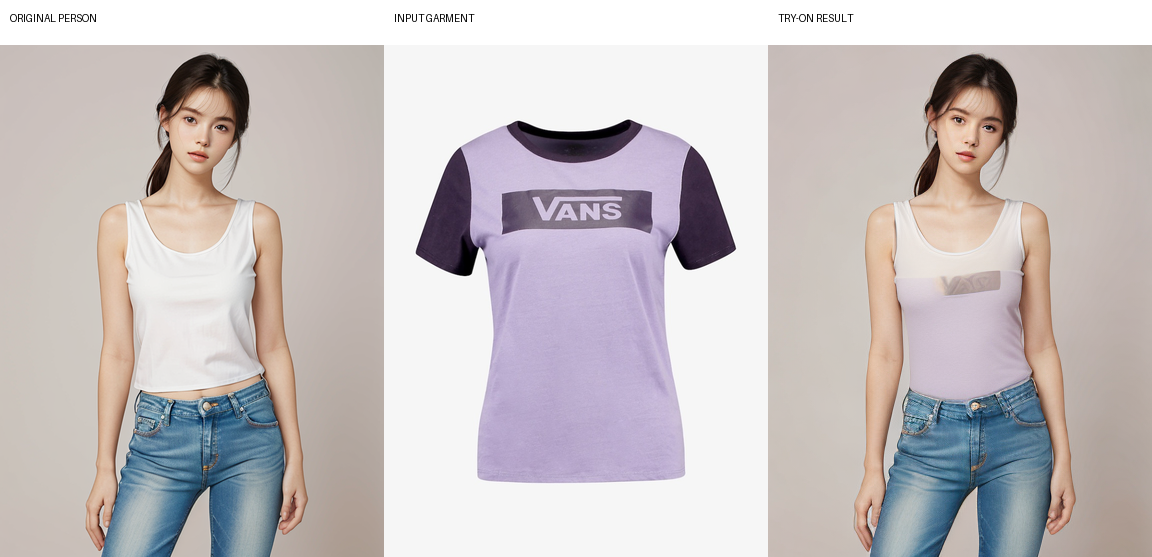

Saved: /content/Smart-TryOn-System/Data/Output/Q4/vlm_judge/pair_01_comparison.png


In [29]:
# ============================================================
# CELL 26 — CREATE PAIR_01 COMPARISON
# ============================================================

row = q4_df[
    q4_df["pair_id"] == "pair_01"
].iloc[0]

person_path = (
    TEST_PAIRS_DIR /
    row["person_image"]
)

garment_path = (
    TEST_PAIRS_DIR /
    row["garment_image"]
)

tryon_path = (
    Q3_RESULTS_DIR /
    f"{row['pair_id']}_tryon.png"
)

comparison_path = (
    VLM_JUDGE_DIR /
    "pair_01_comparison.png"
)

person_image = Image.open(
    person_path
).convert("RGB")

garment_image = Image.open(
    garment_path
).convert("RGB")

tryon_image = Image.open(
    tryon_path
).convert("RGB")

comparison_image = create_vlm_comparison(
    person_image,
    garment_image,
    tryon_image,
    comparison_path
)

display(comparison_image)

print(
    "Saved:",
    comparison_path
)

In [30]:
# ============================================================
# CELL 27 — FLORENCE-2 VLM JUDGE
# ============================================================

def run_vlm_comparison_judge(
    comparison_image
):

    inputs = processor(
        text=VLM_JUDGE_PROMPT,
        images=comparison_image,
        return_tensors="pt"
    )

    # Move tensors to GPU
    prepared_inputs = {}

    for key, value in inputs.items():

        if hasattr(value, "to"):

            prepared_inputs[key] = value.to(
                DEVICE
            )

        else:

            prepared_inputs[key] = value

    with torch.inference_mode():

        generated_ids = (
            florence_model.generate(
                input_ids=prepared_inputs[
                    "input_ids"
                ],
                pixel_values=prepared_inputs[
                    "pixel_values"
                ],
                max_new_tokens=128,
                num_beams=2,
                do_sample=False
            )
        )

    raw_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=False
    )[0]

    parsed = extract_json(
        raw_text
    )

    if parsed is None:

        return {
            "score": None,
            "reasons": raw_text,
            "raw_output": raw_text,
            "status": "json_parse_failed"
        }

    # --------------------------------------------------------
    # Validate score
    # --------------------------------------------------------

    try:

        score = int(
            parsed.get(
                "score"
            )
        )

        score = max(
            1,
            min(
                10,
                score
            )
        )

    except Exception:

        score = None

    reasons = str(
        parsed.get(
            "reasons",
            ""
        )
    )

    return {
        "score": score,
        "reasons": reasons,
        "raw_output": raw_text,
        "status": (
            "success"
            if score is not None
            else "invalid_score"
        )
    }


print(
    "✅ Florence-2 VLM judge ready."
)

✅ Florence-2 VLM judge ready.


In [31]:
# ============================================================
# CELL 27 — FLORENCE-2 VLM JUDGE — DTYPE FIX
# ============================================================

def run_vlm_comparison_judge(comparison_image):

    # --------------------------------------------------------
    # Prepare processor inputs
    # --------------------------------------------------------

    inputs = processor(
        text=VLM_JUDGE_PROMPT,
        images=comparison_image,
        return_tensors="pt"
    )

    # --------------------------------------------------------
    # Move inputs to same device
    # --------------------------------------------------------

    for key in inputs:

        if hasattr(inputs[key], "to"):

            inputs[key] = inputs[key].to(
                DEVICE
            )

    # --------------------------------------------------------
    # IMPORTANT:
    # Florence-2 is loaded in FP16 on CUDA.
    # pixel_values may otherwise remain FP32.
    # --------------------------------------------------------

    if DEVICE == "cuda":

        if "pixel_values" in inputs:

            inputs["pixel_values"] = (
                inputs["pixel_values"]
                .to(dtype=torch.float16)
            )

    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    with torch.inference_mode():

        generated_ids = florence_model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=128,
            num_beams=2,
            do_sample=False
        )

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    raw_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=False
    )[0]

    # --------------------------------------------------------
    # Parse JSON
    # --------------------------------------------------------

    parsed = extract_json(
        raw_text
    )

    if parsed is None:

        return {
            "score": None,
            "reasons": raw_text,
            "status": "json_parse_failed",
            "raw_output": raw_text
        }

    # --------------------------------------------------------
    # Validate score
    # --------------------------------------------------------

    try:

        score = int(
            parsed.get(
                "score",
                0
            )
        )

        score = max(
            1,
            min(
                10,
                score
            )
        )

    except Exception:

        score = None

    return {
        "score": score,
        "reasons": str(
            parsed.get(
                "reasons",
                ""
            )
        ),
        "status": "success",
        "raw_output": raw_text
    }


print(
    "✅ Corrected Florence-2 VLM judge ready."
)

✅ Corrected Florence-2 VLM judge ready.


In [33]:
# ============================================================
# CELL 22A — FLORENCE-2 COMPATIBLE ENVIRONMENT
# ============================================================

!pip install -q "transformers==4.49.0" "tokenizers<0.22"

In [32]:
# ============================================================
# CELL 28 — TEST FLORENCE-2 JUDGE
# ============================================================

print("=" * 70)
print("TESTING FLORENCE-2 VLM JUDGE")
print("=" * 70)

judge_result = run_vlm_comparison_judge(
    comparison_image
)

print()
print("Status :", judge_result["status"])
print("Score  :", judge_result["score"], "/ 10")
print("Reasons:", judge_result["reasons"])

print("=" * 70)

TESTING FLORENCE-2 VLM JUDGE


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
